
###  Assignment 1a
### Part 1
##### Development Environment setup

Screenshot of rye sync command , with python env seen as well in the IDE
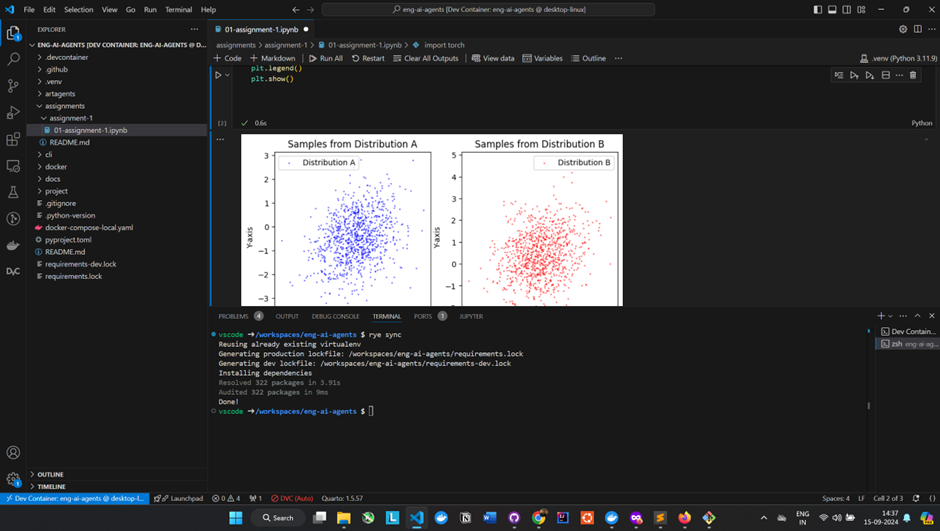

Screenshot of the docker container running
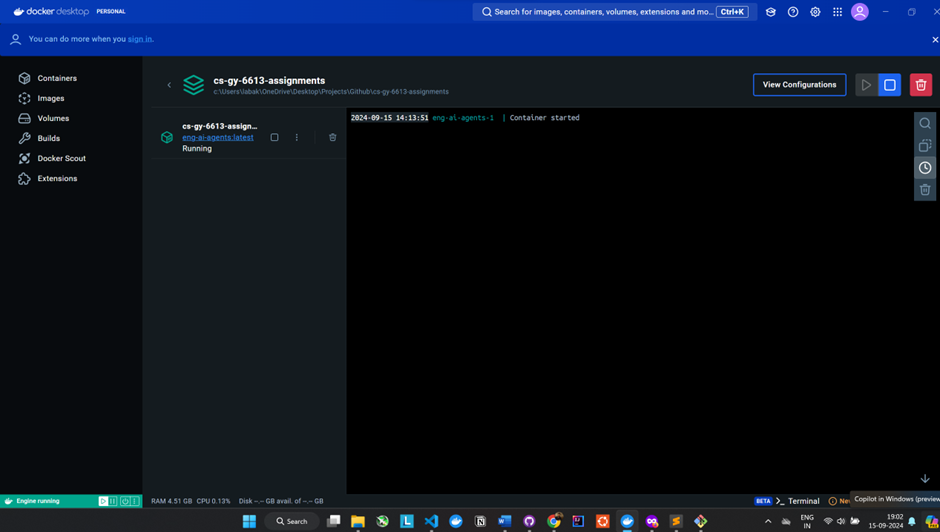

Screenshot of the cloned repo  - running in terminal WSL2
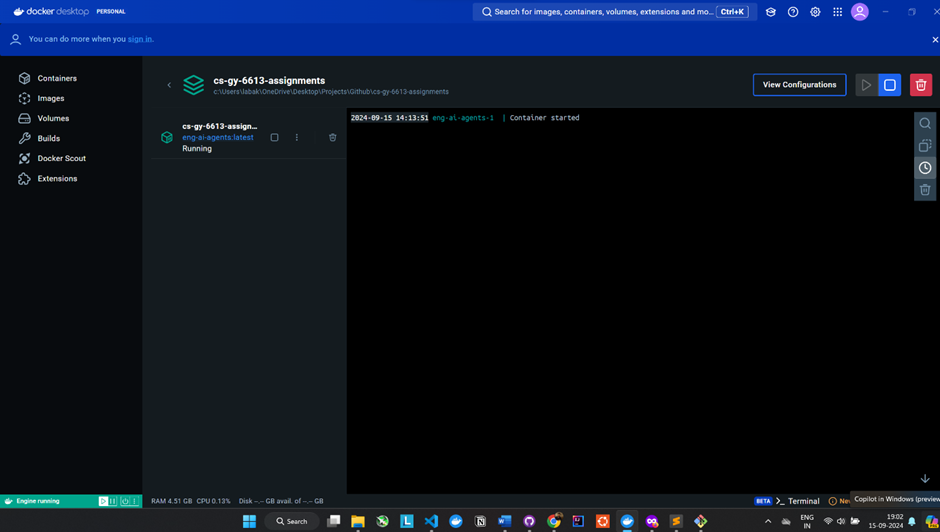




### Part 2
##### Simulation of Multivariate Normal Distribution

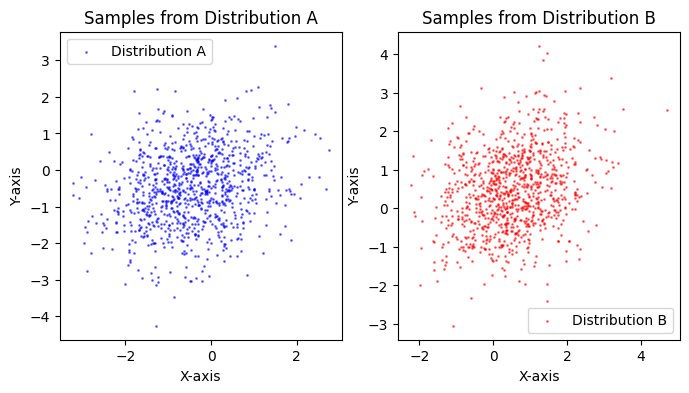

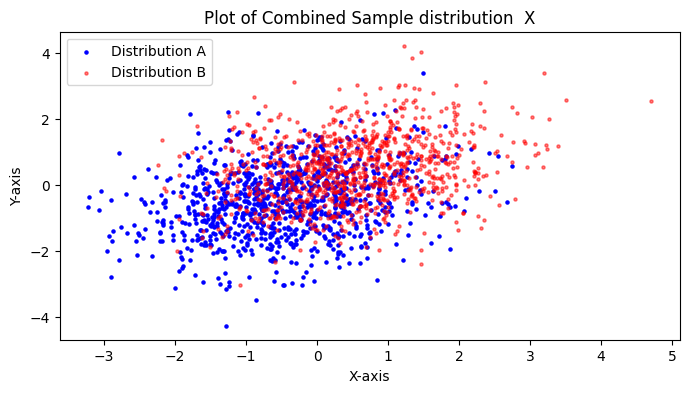

In [17]:
import torch
import matplotlib.pyplot as plt

# Using a NVIDIA GPU - hence using cuda
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# First Bivariate Normal distrubution parameters - according to the assignemnt
# we basically initialize a  1 D tensor , which contains the values for mean
# additionally the device = device serves as a way to run this using GPU
meanA = torch.tensor([-0.5, -0.5], device=device)
covariancMatrixA = torch.tensor([[1.0, 0.25], [0.25, 1.0]], device=device)
distributionA = torch.distributions.MultivariateNormal(meanA, covariancMatrixA)

# Now we are adding the parameters for the second one
meanB= torch.tensor([0.5, 0.5], device=device)
covariancMatrixB = covariancMatrixA # since the covariance in B is same as
distributionB = torch.distributions.MultivariateNormal(meanB, covariancMatrixB)

# Here we get the samples for both distributions
# we need a 1000 samples for both according to the question
samplesOfA = distributionA.sample((1000,))
samplesOfB = distributionB.sample((1000,))


# Scatter plot for samples from Distribution A


plt.figure(figsize=(8, 4))

samplesA_np = samplesOfA.cpu().numpy()
plt.subplot(1, 2, 1)
x_axis_of_A = samplesA_np[:, 0]
y_axis_of_A= samplesA_np[:, 1]
sizeA = 1
alphaA = 0.5 # transparency
plt.scatter(samplesA_np[:, 0], samplesA_np[:, 1], c='blue', s=sizeA, alpha=alphaA, label='Distribution A')
plt.title('Samples from Distribution A')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()


samplesB_np = samplesOfB.cpu().numpy()
plt.subplot(1, 2, 2)
x_axis_of_B = samplesB_np[:, 0]
y_axis_of_B = samplesB_np[:, 1]
sizeB = 1
alphaB = 0.5 # transparency
plt.scatter(x_axis_of_B, y_axis_of_B , c='red', s=sizeB, alpha=alphaB, label='Distribution B')
plt.title('Samples from Distribution B')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()


# now we will combine both into X

# Here we combine both into a single tensor X
X = torch.cat((samplesOfA, samplesOfB), dim=0)
labels = torch.cat((torch.zeros(1000, dtype=torch.long), torch.ones(1000, dtype=torch.long)), dim=0)
Xcpu = X.cpu().numpy()# Move combined samples to CPU for plotting
labelscpu = labels.cpu().numpy()

plt.figure(figsize=(8, 4))
plt.scatter(Xcpu[labelscpu == 0, 0], Xcpu[labelscpu == 0, 1], c='blue', s=5, label='Distribution A', alpha=1)
plt.scatter(Xcpu[labelscpu == 1, 0], Xcpu[labelscpu == 1, 1], c='red', s=5, label='Distribution B', alpha=0.5)

plt.title('Plot of Combined Sample distribution  X')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.show()




### Part 3
##### K - means clustering

Here we implement K means clustering of the data we got in the earlier code


K Means algorithm ran for iterations =
14




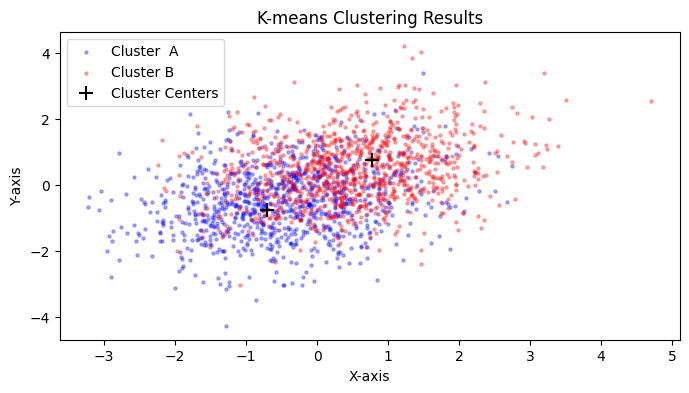

In [18]:

# Function to assign each point to the nearest cluster center
def GetLabelsForEachPoint(X, centroid):
    distances = torch.cdist(X, centroid)  # Compute distances of each data point  to centroid- using builit in distance library of torch
    return torch.argmin(distances, dim=1)

# K-means clustering algorithm
def KMeansClustering(X, k, max_interations):

    # First of all we take two random indexes from our X (since we need a starting point for centroid)
    randomIndexes = torch.randint(0, X.size(0), (k,), dtype=torch.long)
    centroids =X[randomIndexes]

    # 1st iteration
    old_centroids = torch.empty(1,device = device)
    # Get Labels in the first iteration is not expected to give us much of a data , (unless the random index chosen was very very good)
    labels = GetLabelsForEachPoint(X, centroids)
    iterations = 1

    # This is the main part of the algorithm
    # Basically we run the algorithm until the iterrations are over the max , or untill we get a value of centroid exactly equal to the previous
    while iterations < max_interations and not  torch.norm(centroids - old_centroids) == 0 :
        old_centroids = centroids.clone()
        labels = GetLabelsForEachPoint(X, centroids)
        # Getting new centroid value based on the above clustering
        # Groups the centroids basically
        centroids =  torch.stack([X[labels == i].mean(dim=0) for i in range(k)])
        iterations  =    iterations +1

    print("\nK Means algorithm ran for iterations =")
    print(iterations)
    print("\n")
    return centroids, labels



k = 2 # Number of clusters - update this value if needed

# Centroids - gives us the center point basically
# labels will give us the two data we had
centroids, labels = KMeansClustering(X, k,100)


labels_cpu = labels.cpu().numpy()
centroids_cpu = centroids.cpu().numpy()

plt.figure(figsize=(8, 4))
# First print cluster  A
plt.scatter(Xcpu[labelscpu == 0, 0], Xcpu[labelscpu == 0, 1], c='blue', s=5, label='Cluster  A', alpha=0.3)
# Then print cluster  B
plt.scatter(Xcpu[labelscpu == 1, 0], Xcpu[labelscpu == 1, 1], c='red', s=5, label='Cluster B', alpha=0.3)
# Then in the same plot , we also print the centroids we have found
plt.scatter(centroids_cpu [:, 0], centroids_cpu [:, 1], c='black', s=100, marker='+', label='Cluster Centers')  # Plot cluster centers
plt.title('K-means Clustering Results')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.show()

### Part 4
##### Projection with Principal Components Analysis (PCA)
Using the synthetic dataset outlined in the video - Link (https://www.youtube.com/watch?v=l_zvHLIJ53w&t=97s) ,
replicate the steps using pytorch.xyz namespaced libraries to perform PCA on the dataset.

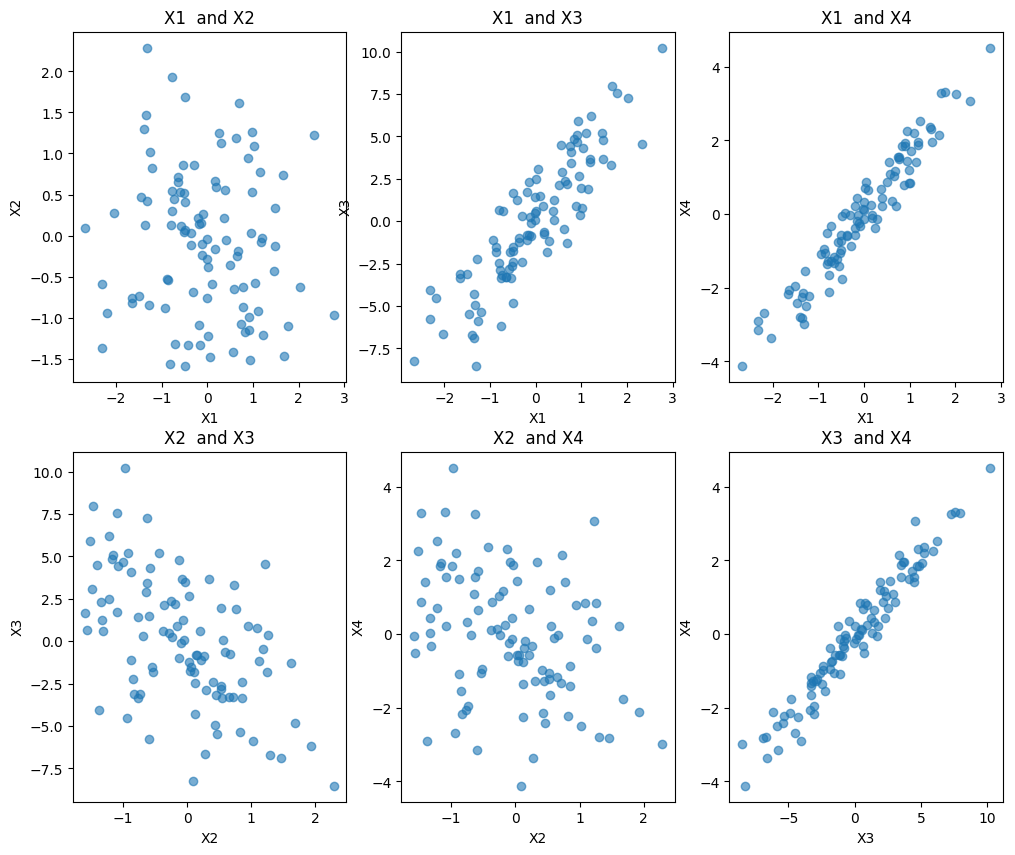

In [19]:
# Generating data
# First we generate first two columns - they are normally distributed
# Not using the earlier distributions here as it is mentioend that we need to use the data given in video


X = torch.normal(mean=torch.zeros(100, 4,device=device), std=torch.ones(100, 4,device=device))
# The other two columns are different linear comibnations of the fist two columns
# as shown in the video we also make the mean of these as 0
X[:, 2] = 3 * X[:, 0] - 2 * X[:, 1] + torch.normal(mean=torch.zeros(100,device=device), std=0.1)
X[:, 3] = 1.5 * X[:, 0] - 0.5 * X[:, 1] + torch.normal(mean=torch.zeros(100,device=device), std=0.1)


## Then  we plot the various data we have now - against each other as shown in video
X_cpu = X.cpu().numpy()
num_features = X_cpu.shape[1]

# Creating the grid for the data given
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 10))
axes = axes.flatten()

# For each two pair of columns we  plot graphs
# Total columns are x1,x2,x4,x4
# Hence the number of ways we can put them against one other is 6
plot_index = 0
for i in range(num_features):
    for j in range(i + 1, num_features):
        if i == j :
            continue

        ax = axes[plot_index]
        ax.scatter(X_cpu[:, i], X_cpu[:, j], alpha=0.6)
        ax.set_xlabel(f'X{i+1}')
        ax.set_ylabel(f'X{j+1}')
        ax.set_title(f'X{i+1}  and X{j+1}')
        plot_index += 1

# as seen in the graphs  , we can observe that
# x1 and x2 are not correlated
# x1 is definetely correlated with x3 and x4 (correlated linearly)
# x2 may be correlated with x3 , x4
# x3 and x4 are also correlated (correlated linearly)



In [20]:

def PrincipalComponentAnalysis(X, num_components):

    mean = torch.mean(X, dim=0)
    X = X - mean
    #compute covariance matrix

    # torch.mm(X_centered.T, X_centered) performs matrix multiplication
    # that is equivalent to summing the outer products of each centered sample.  (which is done in the video in one line)

    covariance_matrix = torch.mm(X.T, X) / (X.size(0)-1)
    #getting the eigenvalues and eigenvectors of covariance matrix
    eigenvalues, eigenvectors = torch.linalg.eig(covariance_matrix)
    eigenvalues = eigenvalues.real  # Extract the real part of eigenvalues
    eigenvectors = eigenvectors.real  # Extract the real part of eigenvectors

    #sort order by magnitude of eigenvalue
    sorted_indices = torch.argsort(eigenvalues, descending=True)
    eigenvectors_sorted = eigenvectors[:, sorted_indices]

    #get eigenvectors
    principal_components = eigenvectors_sorted[:, :num_components]

    X_pca = torch.mm(X, principal_components)

    return X_pca, principal_components

num_components = 4 # 4 to match with the video
X_pca, principal_components = PrincipalComponentAnalysis(X, num_components)

# Print the PCA components
print("Principal Components:")
print(principal_components)




Principal Components:
tensor([[ 0.2256, -0.4787,  0.1993, -0.8248],
        [-0.1050, -0.7987,  0.3042,  0.5084],
        [ 0.8848,  0.1707,  0.3665,  0.2315],
        [ 0.3939, -0.3221, -0.8564,  0.0877]], device='cuda:0')
